In [1]:
import pandas as pd
from pyfaidx import Fasta
from Bio import SeqIO
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
circRNA_df = pd.read_csv("/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/circRNA subcellular localization information.txt",sep = '\t')
localization_df = circRNA_df

In [3]:
circRNA_df

,RNALocate_ID,Species,RNA_Symbol,RNA_Type,Subcellular_Localization,GO_Accession,PubMed_ID,RNALocate_Score
0,RL-E-circ-0938716,Mus musculus,mmu_circ_0001589,circRNA,Cell body,GO:0044297,34934923.0,0.694506
1,RL-E-circ-0938849,Mus musculus,mmu_circ_0000942,circRNA,Cytoplasm,GO:0005737,34751796.0,0.932913
2,RL-E-circ-0938857,Mus musculus,Btnl1,circRNA,Cytoplasm,GO:0005737,36715460.0,0.836757
3,RL-E-circ-0938858,Mus musculus,mmu_circ_0009559,circRNA,Cytoplasm,GO:0005737,38331014.0,0.904945
4,RL-E-circ-0938860,Mus musculus,mmu_circ_0002373,circRNA,Cytoplasm,GO:0005737,37913973.0,0.836757
...,...,...,...,...,...,...,...,...
134179,RL-E-circ-1072892,Homo sapiens,hsa_circ_0063332,circRNA,Extracellular vesicle,GO:1903561,34650036.0,0.694506
134180,RL-E-circ-1072893,Homo sapiens,hsa_circ_0000375,circRNA,Extracellular vesicle,GO:1903561,34650036.0,0.795006
134181,RL-E-circ-1072894,Homo sapiens,hsa_circ_0026102,circRNA,Extracellular vesicle,GO:1903561,34650036.0,0.694506
134182,RL-E-circ-1072896,Homo sapiens,hsa_circ_0000604,circRNA,Stress granule,NaN,35085777.0,0.836757


RNALocate_Score
0.328976    131814
0.396359       871
0.694506       688
0.836757       412
0.795006       168
0.904945        98
0.932913        33
0.815591        33
0.943642        22
0.428658        15
0.890460         8
0.901460         8
0.936216         6
0.441906         5
0.825458         3
Name: count, dtype: int64


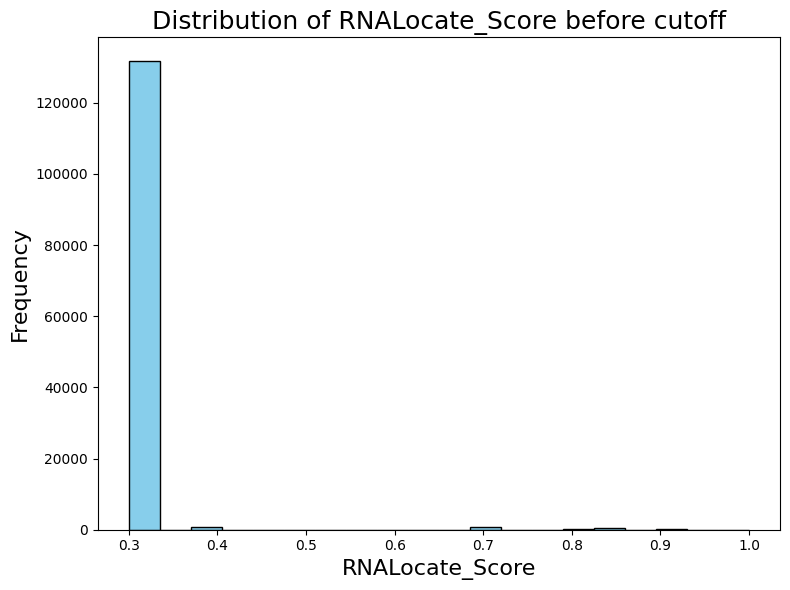

In [4]:
# 打印每种元素的计数
score_counts = circRNA_df['RNALocate_Score'].value_counts()
print(score_counts)

#  提取 RNALocate_Score 列并绘制直方图
plt.figure(figsize=(8, 6))
plt.hist(circRNA_df['RNALocate_Score'], bins=20, range=(0.3, 1.0), color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Distribution of RNALocate_Score before cutoff', fontsize=18)
plt.xlabel('RNALocate_Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)

# 显示图形
plt.tight_layout()
plt.show()


Subcellular_Localization
Extracellular vesicle          79308
Extracellular exosome          52730
Cytoplasm                        880
Nucleus                          482
Cytosol                          433
Membrane                         165
Nucleolus                         63
Nucleoplasm                       47
Chromatin                         46
Mitochondrion                      9
Microvesicle                       8
Stress granule                     2
Outside of the mitochondria        2
Perinuclear                        1
Endosome                           1
Cell body                          1
Around the nucleus                 1
Around the nuclear membrane        1
Ribosome                           1
Neurite                            1
Dendrite                           1
Soma                               1
Name: count, dtype: int64


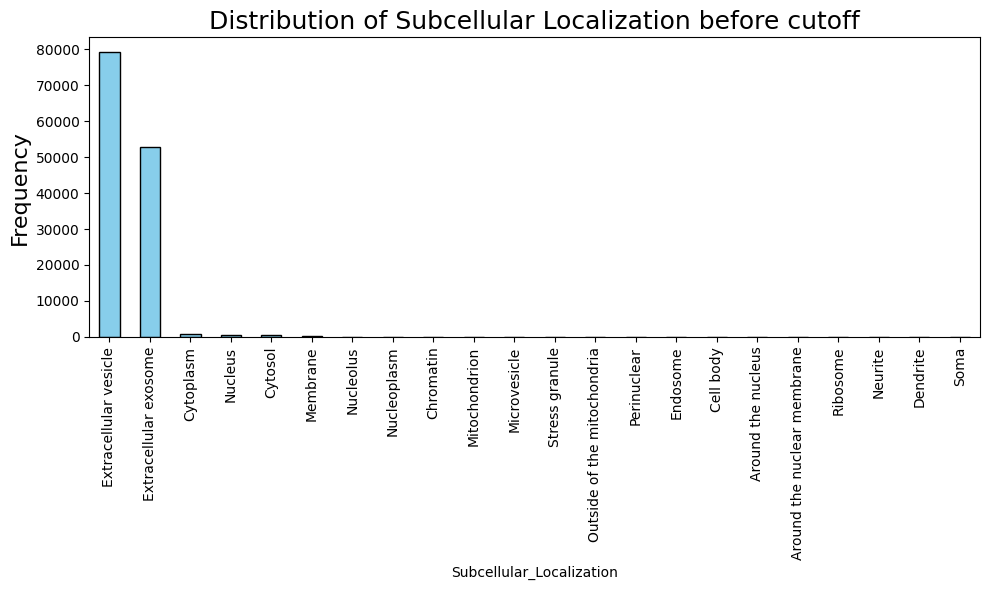

In [5]:
localization_counts = circRNA_df['Subcellular_Localization'].value_counts()

# 打印每种元素的计数
print(localization_counts)

# 绘制柱状图
plt.figure(figsize=(10, 6))
localization_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Distribution of Subcellular Localization before cutoff', fontsize=18)
# plt.xlabel('Subcellular Localization', fontsize=14)
plt.ylabel('Frequency', fontsize=16)

# 显示图形
plt.tight_layout()
plt.show()

截断后还有 134184 行数据


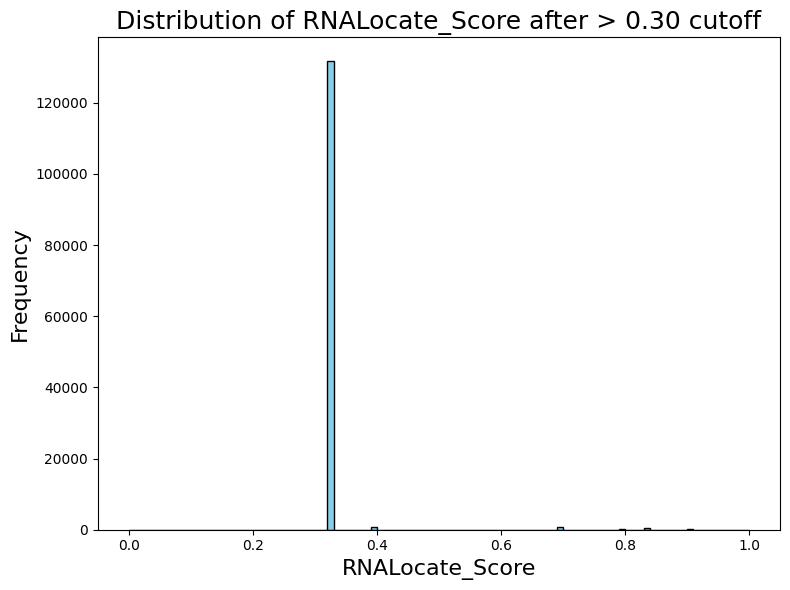

In [6]:
df_filtered = circRNA_df[circRNA_df['RNALocate_Score'] >= 0.30]

# 打印截断后的行数
print(f'截断后还有 {len(df_filtered)} 行数据')

# 绘制截断后的直方图
plt.figure(figsize=(8, 6))
plt.hist(df_filtered['RNALocate_Score'], bins=100, range=(0, 1.0), color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Distribution of RNALocate_Score after > 0.30 cutoff', fontsize=18)
plt.xlabel('RNALocate_Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)

# 显示图形
plt.tight_layout()
plt.show()

Subcellular_Localization
Extracellular vesicle          79308
Extracellular exosome          52730
Cytoplasm                        880
Nucleus                          482
Cytosol                          433
Membrane                         165
Nucleolus                         63
Nucleoplasm                       47
Chromatin                         46
Mitochondrion                      9
Microvesicle                       8
Stress granule                     2
Outside of the mitochondria        2
Perinuclear                        1
Endosome                           1
Cell body                          1
Around the nucleus                 1
Around the nuclear membrane        1
Ribosome                           1
Neurite                            1
Dendrite                           1
Soma                               1
Name: count, dtype: int64


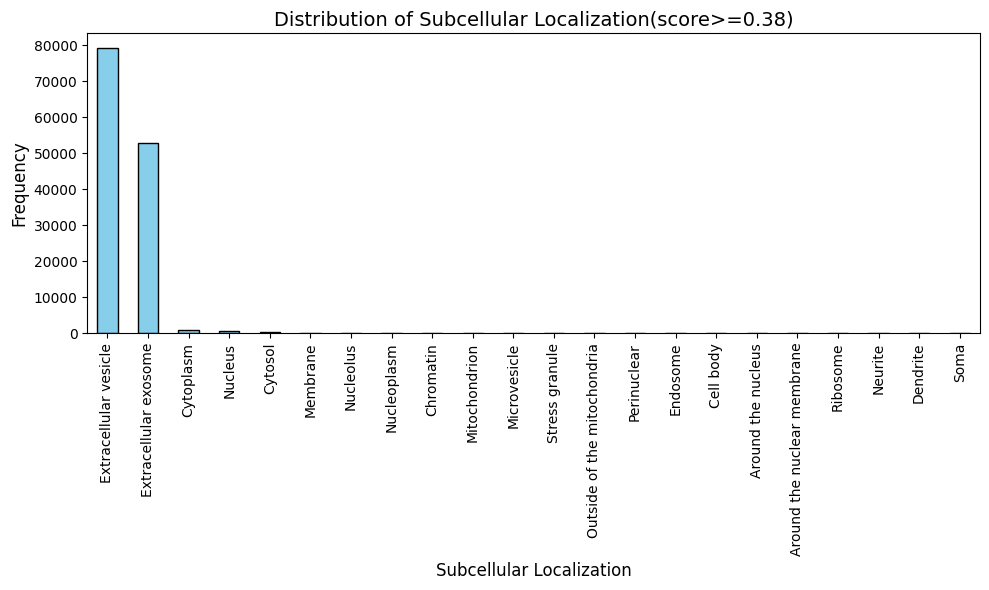

In [7]:
localization_counts = df_filtered['Subcellular_Localization'].value_counts()

# 打印每种元素的计数
print(localization_counts)

# 绘制柱状图
plt.figure(figsize=(10, 6))
localization_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Distribution of Subcellular Localization(score>=0.38)', fontsize=14)
plt.xlabel('Subcellular Localization', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 显示图形
plt.tight_layout()
plt.show()

In [8]:
def process_rna_symbol(symbol):
    # 1. 如果字符串以 novel_ 开头，删除 novel_
    if symbol.startswith("novel_"):
        symbol = symbol[6:] 
    
    # 2. 仅保留包含 'hsa' 的行
    if "hsa" not in symbol and "mmu" not in symbol and "exo" not in symbol:
        return None  # 返回 None 用于之后的行过滤
    
    # 3. 将格式字符串中的piR和hsa调换位置
    parts = symbol.split('-')
    if len(parts) == 3 and parts[0] == "piR":
        symbol = f"hsa-piR-{parts[2]}" 
    
    return symbol

In [9]:
localization_df['RNA_Symbol'] = localization_df['RNA_Symbol'].apply(process_rna_symbol)

localization_df = localization_df[localization_df['RNALocate_Score'] >= 0.30]

# 创建tag列，默认值为0
localization_df['tag'] = 0

# 定义需要标记为1的位置类别
exosome_locations = ['Extracellular exosome', 'Extracellular vesicle', 'Microvesicle']

# 将符合条件的行的tag标记为1
mask = localization_df['Subcellular_Localization'].isin(exosome_locations)
localization_df.loc[mask, 'tag'] = 1

# 删除RNA_Symbol为空的行
localization_df.dropna(subset=['RNA_Symbol'], inplace=True)

In [10]:
fasta_files = [
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/references/circRNA/mouse_mm9_circRNAs_putative_spliced_sequence.fa",
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/references/circRNA/hsa_circbase_seq.fa",
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/references/circRNA/exo_circRNA_sequences.fa",
]

# 定义函数，解析FASTA文件并提取RNA_Symbol和序列
def parse_fasta(file_path):
    seq_dict = {}
    for record in SeqIO.parse(file_path, "fasta"):
        name = record.id
        sequence = str(record.seq)
        # 根据文件来源处理RNA_Symbol
        if "|" in name:  # 第一个文件
            symbol = name.split("|")[0]
        elif "(" in name:  # 第三个文件
            symbol = name.split("(")[0]
        else:  # 第二个文件
            symbol = name
        seq_dict[symbol] = sequence
    return seq_dict

# 合并所有FASTA文件中的RNA_Symbol和序列
rna_sequences = {}
for fasta in fasta_files:
    rna_sequences.update(parse_fasta(fasta))

# 加载CSV文件


# 根据RNA_Symbol添加Sequence列
localization_df["Sequence"] = localization_df.iloc[:, 2].map(rna_sequences).fillna("Sequence_not_found")



In [11]:
localization_df

,RNALocate_ID,Species,RNA_Symbol,RNA_Type,Subcellular_Localization,GO_Accession,PubMed_ID,RNALocate_Score,tag,Sequence
0,RL-E-circ-0938716,Mus musculus,mmu_circ_0001589,circRNA,Cell body,GO:0044297,34934923.0,0.694506,0,ATTGATGAACTCCCAGAGGGAGCTGTGAAGCCTCCAGCAAACAAGT...
1,RL-E-circ-0938849,Mus musculus,mmu_circ_0000942,circRNA,Cytoplasm,GO:0005737,34751796.0,0.932913,0,TTCGAAGGCTGCAAGAAGGCCTTTTCCAGGCTCGAGAACCTCAAGA...
3,RL-E-circ-0938858,Mus musculus,mmu_circ_0009559,circRNA,Cytoplasm,GO:0005737,38331014.0,0.904945,0,GTCTTATGGCAGCGTGTACAAGGCTATTCATAAAGAGACTGGCCAG...
4,RL-E-circ-0938860,Mus musculus,mmu_circ_0002373,circRNA,Cytoplasm,GO:0005737,37913973.0,0.836757,0,GATGACCAGACTCCACTCCACATCTCAGCCCGACTTGGGAAAGCTG...
5,RL-E-circ-0938888,Mus musculus,mmu_circ_0001572,circRNA,Cytoplasm,GO:0005737,33995660.0,0.836757,0,GTTAAAAAATCTCTCTAAGAGCCTGATTTTAGAGTTCACCAGCTCC...
...,...,...,...,...,...,...,...,...,...,...
134179,RL-E-circ-1072892,Homo sapiens,hsa_circ_0063332,circRNA,Extracellular vesicle,GO:1903561,34650036.0,0.694506,1,GTTAAGTTGGAGCCGACTCAGCGGCGGCCGCCATTTTGTGCAGTCG...
134180,RL-E-circ-1072893,Homo sapiens,hsa_circ_0000375,circRNA,Extracellular vesicle,GO:1903561,34650036.0,0.795006,1,GTCCCATCCATGGGGGGGCGGAAGCGGGAGCGCAAGGCTGCCGTCG...
134181,RL-E-circ-1072894,Homo sapiens,hsa_circ_0026102,circRNA,Extracellular vesicle,GO:1903561,34650036.0,0.694506,1,TGGGGGTCCGGTGCGGCGTTGTGCTCTCTGTAACTGCGGGGAGCCC...
134182,RL-E-circ-1072896,Homo sapiens,hsa_circ_0000604,circRNA,Stress granule,NaN,35085777.0,0.836757,0,GCGGGATCGCTTTGTTGGTCAAAGTGAGGGGAAAAAAGCACGACCT...


In [12]:
# 检查 'Sequence' 列是否包含 'N'、"Sequence_not_found" 或为空值，并删除这些行
original_row_count = len(localization_df)  # 原始行数
localization_df = localization_df[
    ~localization_df['Sequence'].str.contains('N', na=False)  # 保留不包含 'N' 的行
]
localization_df = localization_df[
    (localization_df['Sequence'] != "Sequence_not_found") &  # 删除值为 "Sequence_not_found" 的行
    localization_df['Sequence'].notna()  # 删除为空的行
]
new_row_count = len(localization_df)  # 处理后行数

# 计算删除的行数
deleted_rows = original_row_count - new_row_count

# 打印删除的行数
print(f"删除了 {deleted_rows} 行")

删除了 43699 行


平均序列长度: 13870.41
序列长度分布（按分箱）：
49.0 - 23343.3: 73861 条序列
23343.3 - 46637.5: 9575 条序列
46637.5 - 69931.8: 3416 条序列
69931.8 - 93226.1: 1572 条序列
93226.1 - 116520.3: 822 条序列
116520.3 - 139814.6: 486 条序列
139814.6 - 163108.9: 283 条序列
163108.9 - 186403.1: 176 条序列
186403.1 - 209697.4: 69 条序列
209697.4 - 232991.7: 0 条序列
232991.7 - 256285.9: 1 条序列
256285.9 - 279580.2: 0 条序列
279580.2 - 302874.5: 0 条序列
302874.5 - 326168.7: 0 条序列
326168.7 - 349463.0: 0 条序列
349463.0 - 372757.3: 0 条序列
372757.3 - 396051.5: 0 条序列
396051.5 - 419345.8: 0 条序列
419345.8 - 442640.1: 0 条序列
442640.1 - 465934.3: 0 条序列
465934.3 - 489228.6: 0 条序列
489228.6 - 512522.9: 0 条序列
512522.9 - 535817.1: 0 条序列
535817.1 - 559111.4: 1 条序列
559111.4 - 582405.7: 0 条序列
582405.7 - 605699.9: 0 条序列
605699.9 - 628994.2: 0 条序列
628994.2 - 652288.5: 0 条序列
652288.5 - 675582.7: 0 条序列
675582.7 - 698877.0: 1 条序列


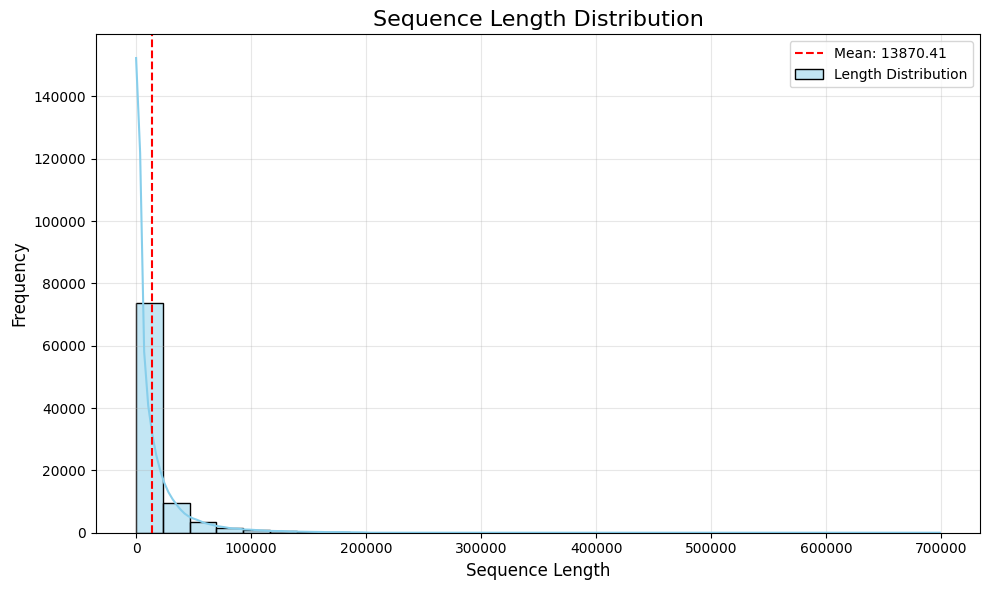

In [13]:
# 计算 Sequence 长度
localization_df['Sequence_Length'] = localization_df['Sequence'].str.len()

# 统计平均值
average_length = localization_df['Sequence_Length'].mean()
print(f"平均序列长度: {average_length:.2f}")

# 设置分箱区间
bins = np.histogram_bin_edges(localization_df['Sequence_Length'], bins=30)  # 自动生成30个分箱
bin_counts, bin_edges = np.histogram(localization_df['Sequence_Length'], bins=bins)

# 打印每个分箱的序列数量
print("序列长度分布（按分箱）：")
for i in range(len(bin_counts)):
    print(f"{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}: {bin_counts[i]} 条序列")

# 绘制分布图
plt.figure(figsize=(10, 6))
sns.histplot(localization_df['Sequence_Length'], bins=bins, kde=True, color='skyblue', label='Length Distribution')

# 添加平均值的标注
plt.axvline(average_length, color='red', linestyle='--', label=f'Mean: {average_length:.2f}')

# 图形细节
plt.title('Sequence Length Distribution', fontsize=16)
plt.xlabel('Sequence Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# 展示图形
plt.show()

In [14]:
# 删除长度过长的circRNA
localization_df['Sequence_Length'] = localization_df['Sequence'].str.len()
original_row_count = len(localization_df)

# 删除 Sequence 长度大于 11238 的行，仍保存于localization_df
localization_df = localization_df[localization_df['Sequence_Length'] <= 11238]
new_row_count = len(localization_df)
deleted_rows = original_row_count - new_row_count
print(f"删除了 {deleted_rows} 行")


删除了 29897 行


最短序列长度: 49
最长序列长度: 11238
平均序列长度: 2675.69

序列长度分布（按分箱）：
49.0 - 422.0: 15201 条序列
422.0 - 794.9: 11023 条序列
794.9 - 1167.9: 5124 条序列
1167.9 - 1540.9: 2981 条序列
1540.9 - 1913.8: 2211 条序列
1913.8 - 2286.8: 1702 条序列
2286.8 - 2659.8: 1550 条序列
2659.8 - 3032.7: 1412 条序列
3032.7 - 3405.7: 1233 条序列
3405.7 - 3778.7: 1297 条序列
3778.7 - 4151.6: 1174 条序列
4151.6 - 4524.6: 1084 条序列
4524.6 - 4897.6: 1059 条序列
4897.6 - 5270.5: 1028 条序列
5270.5 - 5643.5: 974 条序列
5643.5 - 6016.5: 898 条序列
6016.5 - 6389.4: 849 条序列
6389.4 - 6762.4: 923 条序列
6762.4 - 7135.4: 823 条序列
7135.4 - 7508.3: 831 条序列
7508.3 - 7881.3: 813 条序列
7881.3 - 8254.3: 784 条序列
8254.3 - 8627.2: 743 条序列
8627.2 - 9000.2: 712 条序列
9000.2 - 9373.2: 686 条序列
9373.2 - 9746.1: 677 条序列
9746.1 - 10119.1: 690 条序列
10119.1 - 10492.1: 661 条序列
10492.1 - 10865.0: 639 条序列
10865.0 - 11238.0: 584 条序列


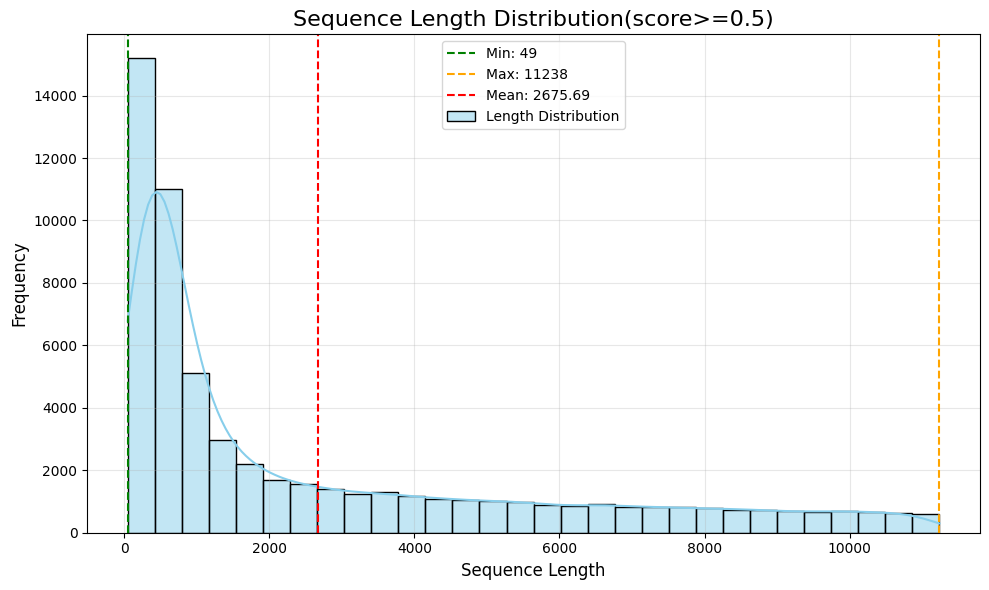

In [15]:
# 计算 Sequence 长度
localization_df['Sequence_Length'] = localization_df['Sequence'].str.len()

# 统计最长、最短和平均值
max_length = localization_df['Sequence_Length'].max()
min_length = localization_df['Sequence_Length'].min()
average_length = localization_df['Sequence_Length'].mean()

print(f"最短序列长度: {min_length}")
print(f"最长序列长度: {max_length}")
print(f"平均序列长度: {average_length:.2f}")

# 设置分箱区间
bins = np.histogram_bin_edges(localization_df['Sequence_Length'], bins=30)  # 自动生成30个分箱
bin_counts, bin_edges = np.histogram(localization_df['Sequence_Length'], bins=bins)

# 打印每个分箱的序列数量
print("\n序列长度分布（按分箱）：")
for i in range(len(bin_counts)):
    print(f"{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}: {bin_counts[i]} 条序列")

# 绘制分布图
plt.figure(figsize=(10, 6))
sns.histplot(localization_df['Sequence_Length'], bins=bins, kde=True, color='skyblue', label='Length Distribution')

# 添加最小值、最大值和平均值的标注
plt.axvline(min_length, color='green', linestyle='--', label=f'Min: {min_length}')
plt.axvline(max_length, color='orange', linestyle='--', label=f'Max: {max_length}')
plt.axvline(average_length, color='red', linestyle='--', label=f'Mean: {average_length:.2f}')

# 图形细节
plt.title('Sequence Length Distribution(score>=0.5)', fontsize=16)
plt.xlabel('Sequence Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# 展示图形
plt.show()

Subcellular_Localization
Extracellular exosome          974
Cytoplasm                      721
Extracellular vesicle          213
Nucleus                        165
Cytosol                         10
Mitochondrion                    7
Nucleolus                        2
Stress granule                   2
Cell body                        1
Dendrite                         1
Neurite                          1
Ribosome                         1
Soma                             1
Around the nuclear membrane      1
Around the nucleus               1
Perinuclear                      1
Name: count, dtype: int64


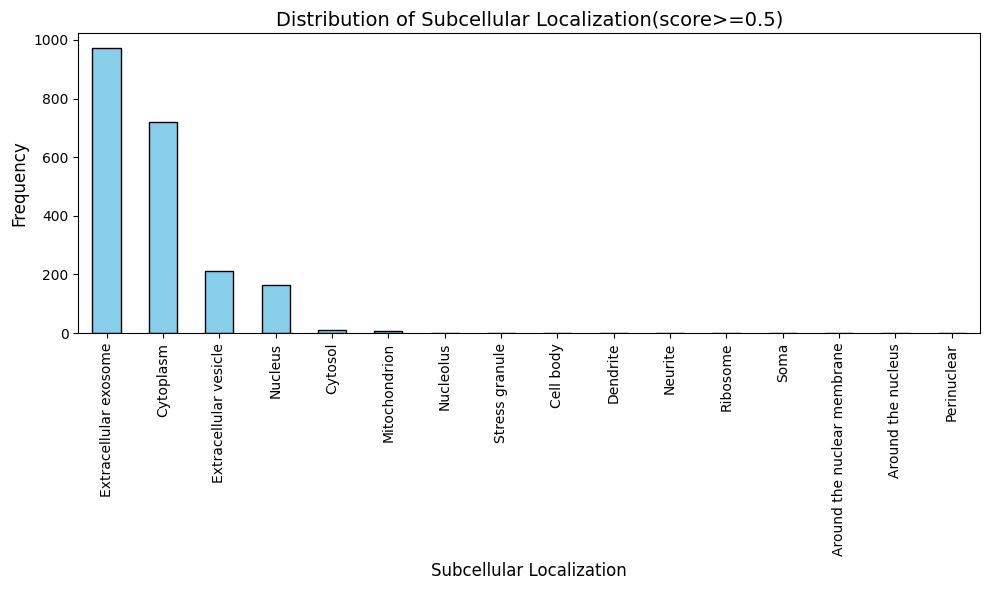

In [18]:
localization_counts = localization_df['Subcellular_Localization'].value_counts()

# 打印每种元素的计数
print(localization_counts)

# 绘制柱状图
plt.figure(figsize=(10, 6))
localization_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Distribution of Subcellular Localization(score>=0.5)', fontsize=14)
plt.xlabel('Subcellular Localization', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 显示图形
plt.tight_layout()
plt.show()

tag
1    58400
0     1966
Name: count, dtype: int64


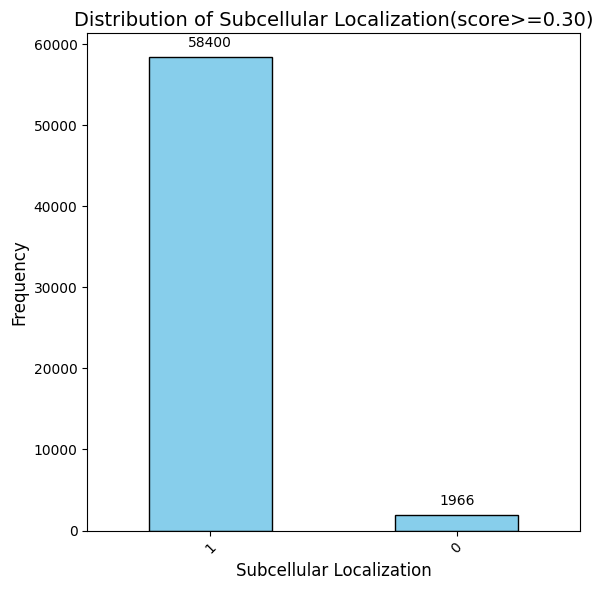

In [17]:

localization_counts = localization_df['tag'].value_counts()

# 打印每种元素的计数
print(localization_counts)

# 绘制柱状图
plt.figure(figsize=(6, 6))
ax = localization_counts.plot(kind='bar', color='skyblue', edgecolor='black', width=0.5)

# 在每个柱子上方添加高度标签
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# 添加标题和标签
plt.title('Distribution of Subcellular Localization(score>=0.30)', fontsize=14)
plt.xlabel('Subcellular Localization', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# plt.ylim(0, 1500)  # 设置y轴范围
plt.xticks(rotation=45)

# 显示图形
plt.tight_layout()
plt.show()

In [18]:
output_csv = "./output_with_sequences.csv"  # 输出CSV文件
localization_df.to_csv(output_csv, sep="\t", index=False)